In [246]:
  %matplotlib inline
  import math
  import numpy as np
  import pandas as pd
  import scipy.stats as stats
  import matplotlib.pyplot as plt
  import matplotlib.pyplot as plt
  import numpy as np
  import random
  import seaborn as sns
  import matplotlib.cm as cm

  from matplotlib.ticker import MaxNLocator
  from matplotlib.pyplot import figure
  from sklearn.preprocessing import MinMaxScaler
  from sklearn.preprocessing import LabelEncoder
  from sklearn.preprocessing import PowerTransformer, RobustScaler, QuantileTransformer, MinMaxScaler
  from sklearn.cluster import KMeans
  from sklearn.metrics import silhouette_score
  from sklearn.model_selection import StratifiedShuffleSplit
  from math import pi
  from sklearn.decomposition import PCA
  from matplotlib.colors import ListedColormap
  from mpl_toolkits.mplot3d import Axes3D
  from sklearn.manifold import TSNE
  from sklearn.metrics import pairwise_distances
  from sklearn.neighbors import NearestNeighbors
  from sklearn.cluster import DBSCAN
  from scipy.cluster.hierarchy import linkage, dendrogram
  from scipy.stats import mode
  from scipy.spatial.distance import pdist
  from sklearn.cluster import AgglomerativeClustering
  from collections import defaultdict
  from collections import defaultdict
  from scipy.stats import pearsonr

In [247]:
cd /home/cal/analysisResults/

/home/cal/analysisResults


In [248]:
def plot_sir_data(df, step=10, title='Changes in Susceptible, Infectious, Recovered'):
    # Pivot the DataFrame to have 'Epoch' as index and 'State' as columns
    df_pivot = df.pivot(index='Epoch', columns='State', values='Count')

    # Determine the maximum y-value for setting the y-axis limit
    max_value = df_pivot.max().max()

    # Downsample the DataFrame to reduce the number of points
    df_pivot_reduced = df_pivot.iloc[::step, :]

    # Plotting the data
    plt.figure(figsize=(6, 3))
    plt.plot(df_pivot_reduced.index, df_pivot_reduced['Susceptible'], marker='o', label='Susceptible')
    plt.plot(df_pivot_reduced.index, df_pivot_reduced['Infectious'], marker='v', label='Infectious')
    plt.plot(df_pivot_reduced.index, df_pivot_reduced['Recovered'], marker='*', label='Recovered')

    # Set y-axis to start from 0
    plt.ylim(0, max_value + 10)

    # Increase font sizes for labels and title
    plt.xlabel('Epoch', fontsize=18)
    plt.ylabel('Count', fontsize=18)
    plt.title(title, fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True)

    # Increase font size for ticks
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.show()


**Average infected, susceptible, recovered with 100 Users and 0 Checkers**

In [249]:
df_data = pd.read_csv('./0CheckersGTSK/Epochs.csv')

In [250]:
df_data

,Epoch,State,Count
0,0,Susceptible,36
1,0,Infectious,63
2,0,Recovered,0
3,1,Susceptible,19
4,1,Infectious,49
...,...,...,...
295,98,Infectious,36
296,98,Recovered,36
297,99,Susceptible,27
298,99,Infectious,36


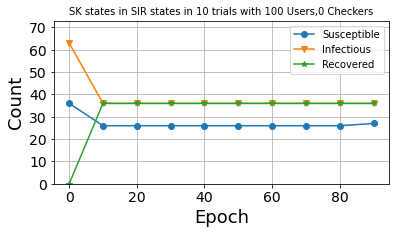

In [251]:
plot_sir_data(df_data,title='SK states in SIR states in 10 trials with 100 Users,0 Checkers')

In [252]:
df_100users0checkersUsers = pd.read_csv('./0CheckersGTSK/UserTrial.csv')

In [253]:
df_100users0checkersPosts = pd.read_csv('./0CheckersGTSK/Post.csv')

**Average infected, susceptible, recovered with 100 Users and 20 Checkers**

In [254]:
df_data = pd.read_csv('./20CheckersSK/Epochs.csv')

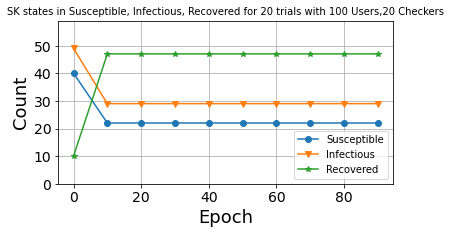

In [255]:
plot_sir_data(df_data,title='SK states in Susceptible, Infectious, Recovered for 20 trials with 100 Users,20 Checkers')

In [256]:
df_100users10checkersUsers = pd.read_csv('./20CheckersSK/UserTrial.csv')

In [257]:
df_100users10checkersPosts = pd.read_csv('./20CheckersSK/Post.csv')

**Average infected, susceptible, recovered in 5 trials with 100 Users and 40 Checkers**

In [258]:
df_data = pd.read_csv('./40CheckersSK/Epochs.csv')

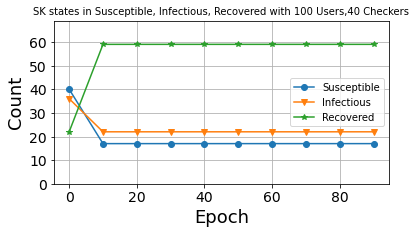

In [259]:
plot_sir_data(df_data,title='SK states in Susceptible, Infectious, Recovered with 100 Users,40 Checkers')

In [260]:
df_100users30checkersUsers = pd.read_csv('./40CheckersSK/UserTrial.csv')

In [261]:
df_100users30checkersPosts = pd.read_csv('./40CheckersSK/Post.csv')

**Average infected, susceptible, recovered 100 Users and 60 Checkers**

In [262]:
df_data = pd.read_csv('./60CheckersSK/Epochs.csv')

In [263]:
df_data

,Epoch,State,Count
0,0,Susceptible,40
1,0,Infectious,23
2,0,Recovered,36
3,1,Susceptible,17
4,1,Infectious,20
...,...,...,...
295,98,Infectious,15
296,98,Recovered,72
297,99,Susceptible,12
298,99,Infectious,15


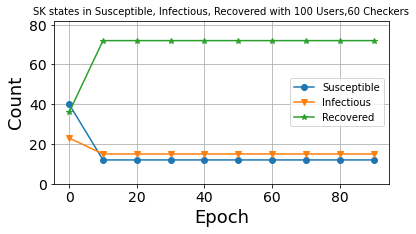

In [264]:
plot_sir_data(df_data,title='SK states in Susceptible, Infectious, Recovered with 100 Users,60 Checkers')

In [265]:
df_100users50checkersUsers = pd.read_csv('./60CheckersSK/UserTrial.csv')

In [266]:
df_100users50checkersPosts = pd.read_csv('./60CheckersSK/Post.csv')

**Average infected, susceptible with 100 Users and 80 Checkers**

In [267]:
df_data = pd.read_csv('./80CheckersSK/Epochs.csv')

In [268]:
df_data

,Epoch,State,Count
0,0,Susceptible,38
1,0,Infectious,10
2,0,Recovered,50
3,1,Susceptible,14
4,1,Infectious,9
...,...,...,...
295,98,Infectious,7
296,98,Recovered,86
297,99,Susceptible,6
298,99,Infectious,7


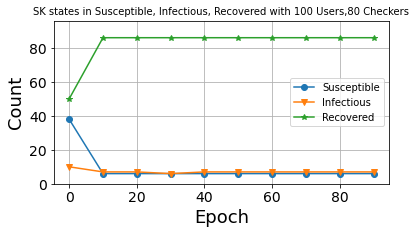

In [269]:
plot_sir_data(df_data,title='SK states in Susceptible, Infectious, Recovered with 100 Users,80 Checkers')

In [270]:
df_100users70checkersUsers = pd.read_csv('./60CheckersSK/UserTrial.csv')

In [271]:
df_100users70checkersPosts = pd.read_csv('./60CheckersSK/Post.csv')

# UsersAggregates

In [272]:
df_100users0checkersUsers['source'] = 'df_100users0checkersUsers'
df_100users10checkersUsers['source'] = 'df_100users10checkersUsers'
df_100users30checkersUsers['source'] = 'df_100users30checkersUsers'
df_100users50checkersUsers['source'] = 'df_100users50checkersUsers'
df_100users70checkersUsers['source'] = 'df_100users70checkersUsers'

# Concatenate DataFrames
df_merged = pd.concat([df_100users0checkersUsers,df_100users10checkersUsers,df_100users30checkersUsers,df_100users50checkersUsers, df_100users70checkersUsers], ignore_index=True)


In [273]:
df_merged

,Total Trials,Average Total Shared Posts,Average Total Fake Shared Posts,Average Total ReShared Posts,Average Total Fake ReShared Posts,Average Total Recovered,Average Total Infectious,Average Total Susceptible,Std Dev Total Shared Posts,Std Dev Total Fake Shared Posts,Std Dev Total ReShared Posts,Std Dev Total Fake ReShared Posts,Std Dev Total Recovered,Std Dev Total Infectious,Std Dev Total Susceptible,source
0,1000,2999.15,1001.640,6995.32,977.857,36.472,36.520,27.008,46.2189,470.575,46.2121,742.617,15.26120,17.7978,14.12770,df_100users0checkersUsers
1,1000,3003.41,838.700,6990.49,669.782,47.335,30.134,22.531,44.6141,396.306,44.5837,497.430,12.51340,14.7050,11.35190,df_100users10checkersUsers
2,1000,2998.82,654.621,6994.91,433.347,59.653,22.685,17.662,47.0923,312.934,47.2147,318.718,10.62120,12.0087,9.07126,df_100users30checkersUsers
3,1000,2999.98,446.738,6993.77,231.386,72.648,15.115,12.237,44.6091,210.348,44.5541,163.163,7.31998,8.0948,6.44196,df_100users50checkersUsers
4,1000,2999.98,446.738,6993.77,231.386,72.648,15.115,12.237,44.6091,210.348,44.5541,163.163,7.31998,8.0948,6.44196,df_100users70checkersUsers


| Averages ± stdev/checkers-skillsmatch   | Average Total ReShared Posts   | Average Total Fake ReShared Posts   | Average Total Recovered<br>(End) | Average Total Infectious<br>(End) | Average Total Susceptible<br>(End) |
|-----------------------------------------|--------------------------------|-------------------------------------|----------------------------------|-----------------------------------|------------------------------------|
| --------------------------------------- | ------------------------------ | ----------------------------------- | -------------------------        | --------------------------        | ----------------------------       |
| 10-1 Dataset                            | 69959.5 ± 134.4                | 18214.0 ± 483.9                     | 23.4 ± 3.9                       | 59.8 ± 6.9                        | 16.8 ± 5.7                         |
| 10-3 Dataset                            | 69999.2 ± 94.4                 | 15990.9 ± 510.4                     | 26.4 ± 2.9                       | 54.1 ± 4.5                        | 19.5 ± 4.9                         |
| 30-1 Dataset                            | 69988.2 ± 152.4                | 12309.2 ± 455.9                     | 37.7 ± 3.5                       | 45.6 ± 6.8                        | 16.7 ± 4.0                         |
| 50.1 Dataset                            | 69951.7 ± 110.2                | 7199.8 ± 487.3                      | 52.0 ± 7.3                       | 34.8 ± 9.7                        | 13.2 ± 4.6                         |
| 70-1 Dataset                            | 70028.7 ± 128.5                | 2766.3 ± 397.1                      | 74.5 ± 2.7                       | 16.3 ± 4.1                        | 9.2 ± 3.0                          |
| 0 Ground Truth                          | 69938.5 ± 184.6                | 22521.9 ± 275.4                     | 20.2 ± 3.4                       | 61.4 ± 7.6                        | 18.4 ± 5.8                         |
| 10 Ground Truth                         | 69964.7 ± 89.9                 | 15984.6 ± 673.8                     | 26.6 ± 3.7                       | 53.5 ± 4.4                        | 19.9 ± 4.7                         |
| 30 Ground Truth                         | 69979.3 ± 120.0                | 7660.6 ± 276.2                      | 40.8 ± 2.5                       | 43.1 ± 4.6                        | 16.1 ± 3.7                         |
| 50 Ground Truth                         | 69972.9 ± 124.5                | 3072.0 ± 299.1                      | 56.7 ± 1.5                       | 27.1 ± 3.1                        | 16.2 ± 3.6                         |
| 70 Ground Truth                         | 70029.6 ± 143.0                | 1028.0 ± 150.3                      | 74.4 ± 2.2                       | 15.4 ± 2.1                        | 10.2 ± 2.7                         |

#PostAggregates

In [274]:
df_100users0checkersPosts

,Metric,Average,StandardDeviation
0,NumberOfPosts,2999.150000,46.242000
1,MaxDepth,23.086000,2.614080
2,MaxBreadth,5.011000,0.495100
3,Size,2.713000,4.283100
4,AverageDepth,2.455880,0.043575
5,AverageBreadth,0.801459,0.026282
6,AverageSize,3.295230,0.063754
7,StdDevSize,4.468850,0.410265
8,NumberOfFakePosts,1001.640000,470.811000
9,MaxDepthFake,10.801000,2.855790


In [275]:
df_100users0checkersPosts= df_100users0checkersPosts.set_index('Metric').T
df_100users10checkersPosts = df_100users10checkersPosts.set_index('Metric').T
df_100users30checkersPosts = df_100users30checkersPosts.set_index('Metric').T
df_100users50checkersPosts = df_100users50checkersPosts.set_index('Metric').T
df_100users70checkersPosts = df_100users70checkersPosts.set_index('Metric').T



In [276]:
df_100users0checkersPosts['source'] = 'df_100users0checkersUsers'
df_100users10checkersPosts['source'] = 'df_100users10checkersUsers'
df_100users30checkersPosts['source'] = 'df_100users30checkersUsers'
df_100users50checkersPosts['source'] = 'df_100users50checkersUsers'
df_100users70checkersPosts['source'] = 'df_100users70checkersUsers'

# Concatenate DataFrames
df_merged = pd.concat([df_100users0checkersPosts,df_100users10checkersPosts,df_100users30checkersPosts,df_100users50checkersPosts, df_100users70checkersPosts], ignore_index=False)


In [277]:
df_merged

Metric,NumberOfPosts,MaxDepth,MaxBreadth,Size,AverageDepth,AverageBreadth,AverageSize,StdDevSize,NumberOfFakePosts,MaxDepthFake,MaxBreadthFake,SizeFake,NumberOfTruePosts,MaxDepthTrue,MaxBreadthTrue,SizeTrue,source
Average,2999.1500,23.08600,5.011000,2.71300,2.455880,0.801459,3.295230,4.468850,1001.640,10.80100,3.723000,1.890160,1997.510,23.08600,4.989000,4.049400,df_100users0checkersUsers
StandardDeviation,46.2420,2.61408,0.495100,4.28310,0.043575,0.026282,0.063754,0.410265,470.811,2.85579,0.645514,0.303757,469.843,2.61408,0.507086,0.417761,df_100users0checkersUsers
Average,3003.4100,23.32700,5.000000,2.62700,2.449730,0.794933,3.293640,4.620340,838.700,9.92700,3.543000,1.731820,2164.710,23.32700,4.996000,3.934450,df_100users10checkersUsers
StandardDeviation,44.6365,2.76835,0.506218,3.99197,0.041593,0.025199,0.058382,0.241826,396.505,3.03593,0.657711,0.227662,396.788,2.76835,0.510141,0.350215,df_100users10checkersUsers
Average,2998.8200,23.30400,5.023000,2.68300,2.448210,0.790267,3.305910,4.708090,654.621,10.38800,3.422000,1.606890,2344.200,23.29300,5.015000,3.798610,df_100users30checkersUsers
StandardDeviation,47.1158,2.60622,0.478226,4.14484,0.042090,0.027451,0.057233,0.200073,313.091,3.55163,0.684386,0.178050,313.732,2.60537,0.484778,0.263554,df_100users30checkersUsers
Average,2999.9800,22.93200,5.010000,2.54800,2.454370,0.792164,3.312950,4.704940,446.738,10.11300,3.281000,1.480760,2553.240,22.92300,5.005000,3.640470,df_100users50checkersUsers
StandardDeviation,44.6314,2.64507,0.456189,4.21562,0.036718,0.024582,0.050970,0.195442,210.453,3.62372,0.684476,0.139401,214.461,2.64501,0.459550,0.172844,df_100users50checkersUsers
Average,2999.9800,22.93200,5.010000,2.54800,2.454370,0.792164,3.312950,4.704940,446.738,10.11300,3.281000,1.480760,2553.240,22.92300,5.005000,3.640470,df_100users70checkersUsers
StandardDeviation,44.6314,2.64507,0.456189,4.21562,0.036718,0.024582,0.050970,0.195442,210.453,3.62372,0.684476,0.139401,214.461,2.64501,0.459550,0.172844,df_100users70checkersUsers


|   |     | Averages ± stdev/checkers-skillsmatch   | NumberOfPosts          | NumberOfFakePosts     | NumberOfTruePosts     |
|---|-----|-----------------------------------------|------------------------|-----------------------|-----------------------|
|   | --- | --------------------------------------- | ---------------------- | --------------------- | --------------------- |
|   |     | 10-1 Dataset                            | 30033.9 ± 140.0        | 15365.8 ± 113.9       | 14668.1 ± 107.6       |
|   |     | 10-3 Dataset                            | 29995.1 ± 97.8         | 14930.7 ± 118.4       | 15064.4 ± 74.9        |
|   |     | 30-1 Dataset                            | 30005.0 ± 160.8        | 12471.1 ± 200.3       | 17533.9 ± 119.7       |
|   |     | 50.1 Dataset                            | 30043.6 ± 115.0        | 9132.8 ± 190.1        | 20910.8 ± 215.7       |
|   |     | 70-1 Dataset                            | 29963.4 ± 135.7        | 5331.2 ± 147.3        | 24632.2 ± 221.5       |
|   |     | 0 Ground Truth                          | 30056.8 ± 192.2        | 16866.6 ± 159.8       | 13190.2 ± 145.2       |
|   |     | 10 Ground Truth                         | 30030.7 ± 96.7         | 14869.4 ± 129.5       | 15161.3 ± 96.8        |
|   |     | 30 Ground Truth                         | 30012.9 ± 127.8        | 11332.6 ± 101.7       | 18680.3 ± 104.5       |
|   |     | 50 Ground Truth                         | 30021.9 ± 129.8        | 7921.8 ± 88.2         | 22100.1 ± 110.0       |
|   |     | 70 Ground Truth                         | 29964.0 ± 151.1        | 4679.6 ± 64.2         | 25284.4 ± 143.7       |

| Averages ± stdev/checkers-skillsmatch   | TreeMaxDepthFake   | TreeMaxBreadthFake | TreeSizeFake       | TreeMaxDepthTrue   | TreeMaxBreadthTrue | TreeSizeTrue       |
|-----------------------------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|
| --------------------------------------- | ------------------ | ------------------ | ------------------ | ------------------ | ------------------ | ------------------ |
| 10-1 Dataset                            | 18.3 ± 2.16        | 4.8 ± 0.63         | 2.19 ± 0.03        | 27.2 ± 1.55        | 5.5 ± 0.53         | 4.40 ± 0.04        |
| 10-3 Dataset                            | 16.0 ± 2.67        | 4.8 ± 0.63         | 2.07 ± 0.03        | 25.8 ± 1.48        | 5.7 ± 0.48         | 4.33 ± 0.04        |
| 30-1 Dataset                            | 18.2 ± 1.69        | 4.4 ± 0.52         | 1.99 ± 0.03        | 27.9 ± 1.79        | 5.8 ± 0.42         | 4.21 ± 0.03        |
| 50.1 Dataset                            | 20.0 ± 2.79        | 4.7 ± 0.48         | 1.79 ± 0.05        | 27.6 ± 2.01        | 5.9 ± 0.32         | 3.95 ± 0.01        |
| 70-1 Dataset                            | 20.1 ± 2.47        | 4.4 ± 0.70         | 1.52 ± 0.07        | 27.7 ± 1.57        | 5.7 ± 0.67         | 3.71 ± 0.02        |
| 0 Ground Truth                          | 18.6 ± 1.78        | 5.3 ± 0.48         | 2.34 ± 0.02        | 27.2 ± 1.48        | 5.6 ± 0.52         | 4.46 ± 0.04        |
| 10 Ground Truth                         | 14.9 ± 1.20        | 4.7 ± 0.48         | 2.07 ± 0.04        | 27.5 ± 2.88        | 5.6 ± 0.52         | 4.43 ± 0.06        |
| 30 Ground Truth                         | 10.9 ± 1.73        | 4.1 ± 0.57         | 1.68 ± 0.02        | 28.5 ± 2.37        | 5.7 ± 0.48         | 4.26 ± 0.04        |
| 50 Ground Truth                         | 7.2 ± 0.63         | 3.7 ± 0.48         | 1.39 ± 0.04        | 26.4 ± 1.51        | 5.9 ± 0.57         | 3.99 ± 0.04        |
| 70 Ground Truth                         | 5.7 ± 0.67         | 2.8 ± 0.42         | 1.22 ± 0.03        | 28.0 ± 2.36        | 5.8 ± 0.42         | 3.71 ± 0.02        |